# Importing Packages

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

RSEED=42

# Importing the Data

In [215]:
# Import diabetes data
df = pd.read_csv('./../Data/Train.csv')
df.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,...,49.839714,-78.342701,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,...,29.181258,-73.896588,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,...,0.797294,-68.612480,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 82 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-nul

In [217]:
df.isnull().sum()

Place_ID X Date                     0
Date                                0
Place_ID                            0
target                              0
target_min                          0
                                ...  
L3_CH4_aerosol_optical_depth    24765
L3_CH4_sensor_azimuth_angle     24765
L3_CH4_sensor_zenith_angle      24765
L3_CH4_solar_azimuth_angle      24765
L3_CH4_solar_zenith_angle       24765
Length: 82, dtype: int64

# EDA 1

In [218]:
cols_to_drop = [
    "Place_ID X Date",
    "target_min",
    "target_max",
    "target_variance",
    "target_count",
    "L3_CH4_CH4_column_volume_mixing_ratio_dry_air",
    "L3_CH4_aerosol_height",
    "L3_CH4_aerosol_optical_depth",
    "L3_CH4_sensor_azimuth_angle",
    "L3_CH4_sensor_zenith_angle",
    "L3_CH4_solar_azimuth_angle",
    "L3_CH4_solar_zenith_angle"
]


df = df.drop(columns=cols_to_drop)
df.head()

,Date,Place_ID,target,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,...,L3_AER_AI_solar_zenith_angle,L3_SO2_SO2_column_number_density,L3_SO2_SO2_column_number_density_amf,L3_SO2_SO2_slant_column_number_density,L3_SO2_absorbing_aerosol_index,L3_SO2_cloud_fraction,L3_SO2_sensor_azimuth_angle,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle
0,2020-01-02,010Q650,38.0,11.000000,60.200001,0.00804,18.516840,1.996377,-1.227395,0.000074,...,22.358167,-0.000127,0.312521,-0.000040,-1.861476,0.000000,76.536426,38.593017,-61.752587,22.363665
1,2020-01-03,010Q650,39.0,14.600000,48.799999,0.00839,22.546533,3.330430,-1.188108,0.000076,...,28.614804,0.000150,0.433957,0.000050,-1.452612,0.059433,-14.708036,59.624912,-67.693509,28.614804
2,2020-01-04,010Q650,24.0,16.400000,33.400002,0.00750,27.031030,5.065727,3.500559,0.000067,...,34.296977,0.000150,0.356925,0.000053,-1.572950,0.082063,-105.201338,49.839714,-78.342701,34.296977
3,2020-01-05,010Q650,49.0,6.911948,21.300001,0.00391,23.971857,3.004001,1.099468,0.000083,...,30.545393,0.000227,0.584522,0.000110,-1.239317,0.121261,-104.334066,29.181258,-73.896588,30.545446
4,2020-01-06,010Q650,21.0,13.900001,44.700001,0.00535,16.816309,2.621787,2.670559,0.000070,...,26.899694,0.000390,0.408047,0.000159,0.202489,0.037919,58.850179,0.797294,-68.612480,26.899694


In [219]:
df['Place_ID'].value_counts()

Place_ID
010Q650    94
JSXAVKO    94
I5RGE5G    94
I6718VY    94
I6VIR8R    94
           ..
LKE9VQB    41
S91MBTB    29
6KAHP8X    12
MJSB8K5     7
5IUK9TG     3
Name: count, Length: 340, dtype: int64

In [220]:
df['Date'].value_counts().sort_index()

Date
2020-01-02    324
2020-01-03    327
2020-01-04    329
2020-01-05    331
2020-01-06    327
             ... 
2020-03-31    326
2020-04-01    328
2020-04-02    329
2020-04-03    330
2020-04-04    323
Name: count, Length: 94, dtype: int64

In [221]:
# 1. Filter: Keep only Place_IDs that have at least 40 entries
# We group by the column (axis=0 is default), not the headers (axis=1)
df = df.replace(0, np.nan)
df = df.groupby('Place_ID', as_index=False).filter(lambda x: len(x) >= 40)

# 2. Sort: Ensure time-series order for interpolation to make sense
# If 'Date' isn't a datetime object yet, you might want: df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Place_ID', 'Date'])

# 3. Interpolate: Fill missing values within each group
# We use group_keys=False to prevent the Place_ID from becoming a redundant index
df = df.groupby('Place_ID', as_index=False).apply(lambda x: x.interpolate(limit_direction='both'))

# Check the results
df['Place_ID'].value_counts()

Place_ID
010Q650    94
XY3IU5C    94
I5RGE5G    94
I6718VY    94
I6VIR8R    94
           ..
XJJSC4X    49
1Y0S7TZ    49
U91NAMJ    48
T5P5MTS    42
LKE9VQB    41
Name: count, Length: 336, dtype: int64

In [222]:
df.isnull().sum()

Date                                    0
Place_ID                                0
target                                  0
precipitable_water_entire_atmosphere    0
relative_humidity_2m_above_ground       0
                                       ..
L3_SO2_cloud_fraction                   0
L3_SO2_sensor_azimuth_angle             0
L3_SO2_sensor_zenith_angle              0
L3_SO2_solar_azimuth_angle              0
L3_SO2_solar_zenith_angle               0
Length: 70, dtype: int64

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 30506 entries, (0, 0) to (335, 30556)
Data columns (total 70 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Date                                                 30506 non-null  object 
 1   Place_ID                                             30506 non-null  object 
 2   target                                               30506 non-null  float64
 3   precipitable_water_entire_atmosphere                 30506 non-null  float64
 4   relative_humidity_2m_above_ground                    30506 non-null  float64
 5   specific_humidity_2m_above_ground                    30506 non-null  float64
 6   temperature_2m_above_ground                          30506 non-null  float64
 7   u_component_of_wind_10m_above_ground                 30506 non-null  float64
 8   v_component_of_wind_10m_above_ground                 3

# Feature Engineering

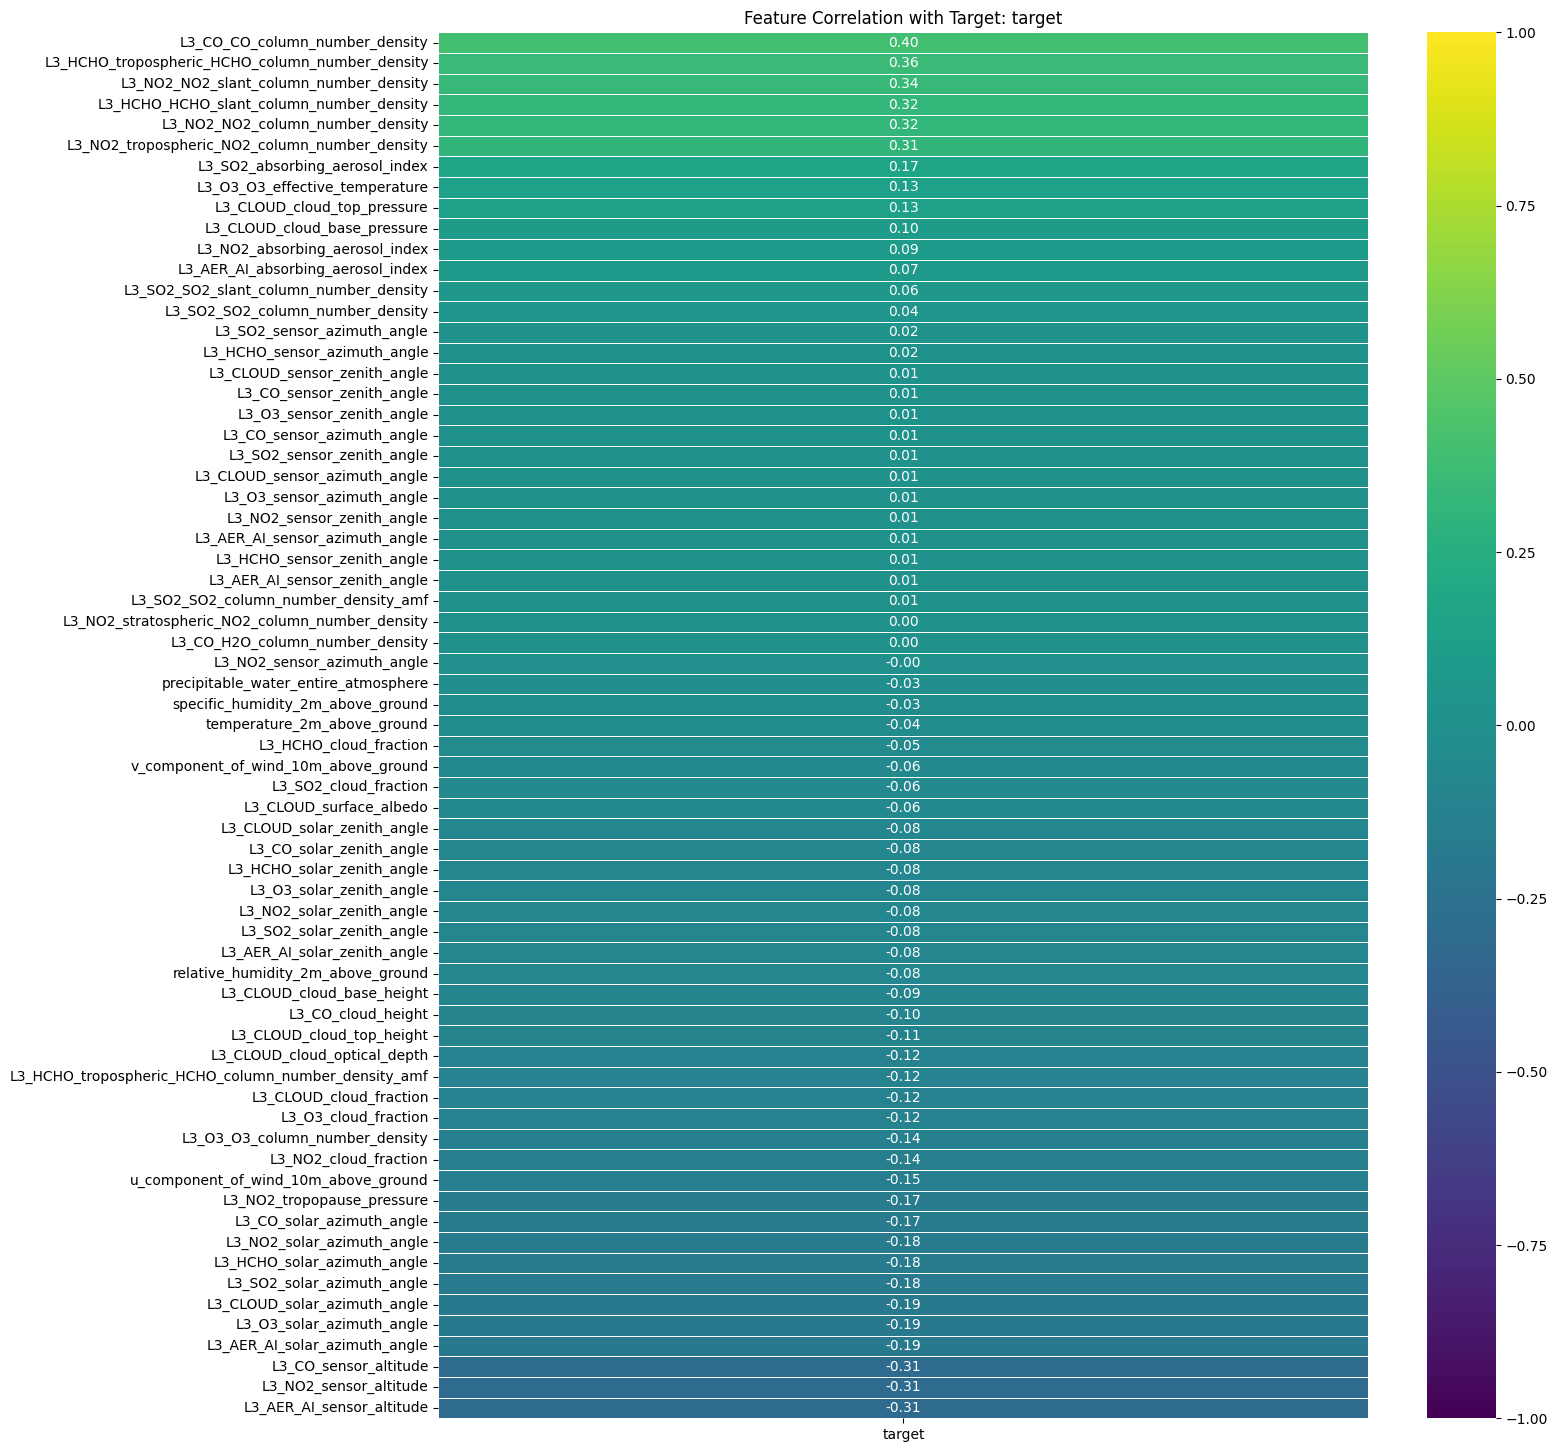

In [224]:
def plot_target_correlation(data, target_col, title="Feature Correlation with Target"):
    """Plots a sorted heatmap showing the correlation of all features with the target."""
    correlations = data.corr(numeric_only=True)[[target_col]]
    correlations = correlations.sort_values(by=target_col, ascending=False)
    correlations = correlations.drop(target_col)

    plt.figure(figsize=(15, 18))
    sns.heatmap(correlations, annot=True, cmap='viridis',
                vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
    plt.title(f"{title}: {target_col}")
    plt.show()

plot_target_correlation(df, "target")

In [225]:
def relative_mean_angles(df: pd.DataFrame):
    angle_map = {
        'solar_azimuth': [col for col in df.columns if 'solar_azimuth_angle' in col],
        'sensor_azimuth': [col for col in df.columns if 'sensor_azimuth_angle' in col],
        'solar_zenith': [col for col in df.columns if 'solar_zenith_angle' in col],
        'sensor_zenith': [col for col in df.columns if 'sensor_zenith_angle' in col]
    }

    mean_var = pd.DataFrame()
    for name, cols in angle_map.items():
        mean_var[f'mean_{name}'] = df[cols].mean(axis=1)

    df['relative_azimuth'] = np.abs(mean_var['mean_solar_azimuth'] - mean_var['mean_sensor_azimuth'])


    df['relative_zenith'] = np.abs(mean_var['mean_solar_zenith'] - mean_var['mean_sensor_zenith'])

    # Calculate Air Mass Factor Proxy (1 / cos(solar_zenith))
    # This is physically significant for light path length through the atmosphere
    #df['solar_zenith_rad'] = np.radians(df['mean_solar_zenith'])
    #df['air_mass_factor_proxy'] = 1 / np.cos(df['solar_zenith_rad'])

    # 5. Clean up: Remove all the original redundant angle columns
    all_original_angles = [col for list_of_cols in angle_map.values() for col in list_of_cols]
    df.drop(columns=all_original_angles, inplace=True)
    #df.drop(columns=all_original_angles + ['solar_zenith_rad'], inplace=True)

    print(f"Reduced features. New columns added: {list(df.columns[-6:])}")
    return df

df = relative_mean_angles(df)

Reduced features. New columns added: ['L3_SO2_SO2_column_number_density_amf', 'L3_SO2_SO2_slant_column_number_density', 'L3_SO2_absorbing_aerosol_index', 'L3_SO2_cloud_fraction', 'relative_azimuth', 'relative_zenith']


In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 30506 entries, (0, 0) to (335, 30556)
Data columns (total 44 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Date                                                 30506 non-null  object 
 1   Place_ID                                             30506 non-null  object 
 2   target                                               30506 non-null  float64
 3   precipitable_water_entire_atmosphere                 30506 non-null  float64
 4   relative_humidity_2m_above_ground                    30506 non-null  float64
 5   specific_humidity_2m_above_ground                    30506 non-null  float64
 6   temperature_2m_above_ground                          30506 non-null  float64
 7   u_component_of_wind_10m_above_ground                 30506 non-null  float64
 8   v_component_of_wind_10m_above_ground                 3

In [227]:
def calculate_air_mass_factors(df):
    """
    Calculates the ratio between slant and vertical columns.
    Matches exact column names from your df.info().
    """
    # NO2 AMF
    df['AMF_NO2'] = df['L3_NO2_NO2_slant_column_number_density'] / df['L3_NO2_NO2_column_number_density']
    
    # SO2 AMF (Using the slant and column density)
    df['AMF_SO2_calc'] = df['L3_SO2_SO2_slant_column_number_density'] / df['L3_SO2_SO2_column_number_density']
    
    # HCHO AMF (Using slant and tropospheric column density)
    df['AMF_HCHO_calc'] = df['L3_HCHO_HCHO_slant_column_number_density'] / df['L3_HCHO_tropospheric_HCHO_column_number_density']
    
    return df

def calculate_atmospheric_indices(df):
    """
    Calculates environmental ratios and cloud metrics.
    """
    # NO2 Tropo Ratio: How much of the total NO2 is in the troposphere?
    df['NO2_Tropo_Ratio'] = df['L3_NO2_tropospheric_NO2_column_number_density'] / df['L3_NO2_NO2_column_number_density']
    
    # Cloud pressure thickness (Base - Top)
    df['Cloud_Thickness_Pressure'] = df['L3_CLOUD_cloud_base_pressure'] - df['L3_CLOUD_cloud_top_pressure']
    
    return df

# --- How to use them ---
df = calculate_air_mass_factors(df)
df = calculate_atmospheric_indices(df)

In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 30506 entries, (0, 0) to (335, 30556)
Data columns (total 49 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Date                                                 30506 non-null  object 
 1   Place_ID                                             30506 non-null  object 
 2   target                                               30506 non-null  float64
 3   precipitable_water_entire_atmosphere                 30506 non-null  float64
 4   relative_humidity_2m_above_ground                    30506 non-null  float64
 5   specific_humidity_2m_above_ground                    30506 non-null  float64
 6   temperature_2m_above_ground                          30506 non-null  float64
 7   u_component_of_wind_10m_above_ground                 30506 non-null  float64
 8   v_component_of_wind_10m_above_ground                 3

# Baseline Model